### Clasificación de Supervivencia en Cáncer de Mama usando KNN

Este dataset contiene casos de un estudio realizado sobre la supervivencia de pacientes que se sometieron a cirugía por cáncer de mama en el Hospital Hamerman, Chicago, entre 1958 y 1970.

**Número de Instancias:** 306

**Número de Atributos:** 4 (incluyendo el atributo de clase)

**Información de los Atributos:**
1.  **Edad** (`Edad`): Edad del paciente en el momento de la operación (numérico).
2.  **Año de Operación** (`Año_Operacion`): Año en que el paciente fue operado (numérico). (Por ejemplo, el año '64' se refiere a 1964).
3.  **Ganglios Axilares Positivos** (`Ganglios_Axilares`): Número de ganglios axilares positivos detectados (numérico).
4.  **Estado de Supervivencia** (`Estado_Supervivencia`): Atributo de clase (categórico):
    *   **1**: el paciente sobrevivió 5 años o más.
    *   **2**: el paciente murió dentro de los 5 años.

**Valores de Atributos Faltantes:** Ninguno.

# Librearias

In [1]:
!pip install scikit-optimize
!pip install imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE, RandomOverSampler, ADASYN
from imblearn.combine import SMOTETomek
from skopt import BayesSearchCV
from skopt.space import Categorical, Integer
from tqdm.notebook import tqdm

# Descarga del Dataset

In [2]:
# 1. CARGA Y ENTENDIMIENTO DEL DATASET
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
column_names = ['Edad', 'Año_Operacion', 'Ganglios_Axilares', 'Estado_Supervivencia']
df = pd.read_csv(url, names=column_names)

#EDA

#### Distribución de las características (Histogramas)

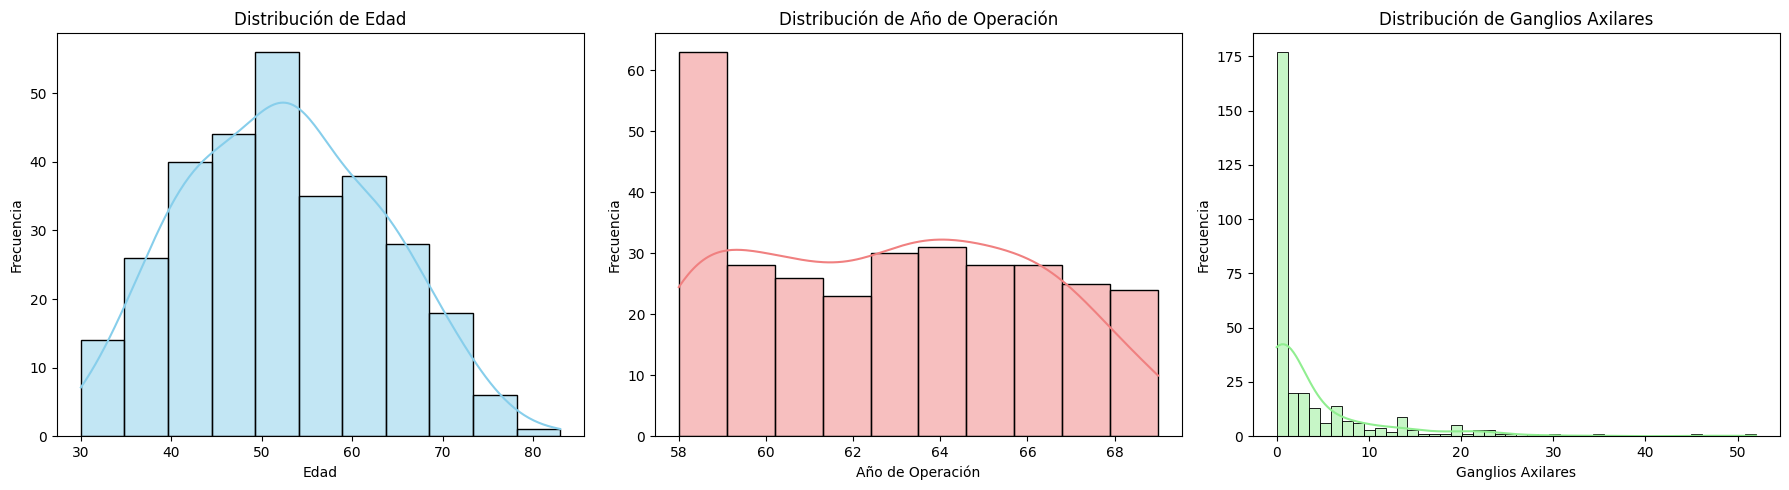

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Edad'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

sns.histplot(df['Año_Operacion'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribución de Año de Operación')
axes[1].set_xlabel('Año de Operación')
axes[1].set_ylabel('Frecuencia')

sns.histplot(df['Ganglios_Axilares'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribución de Ganglios Axilares')
axes[2].set_xlabel('Ganglios Axilares')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

#### Relación de características con el estado de supervivencia (Box Plots)

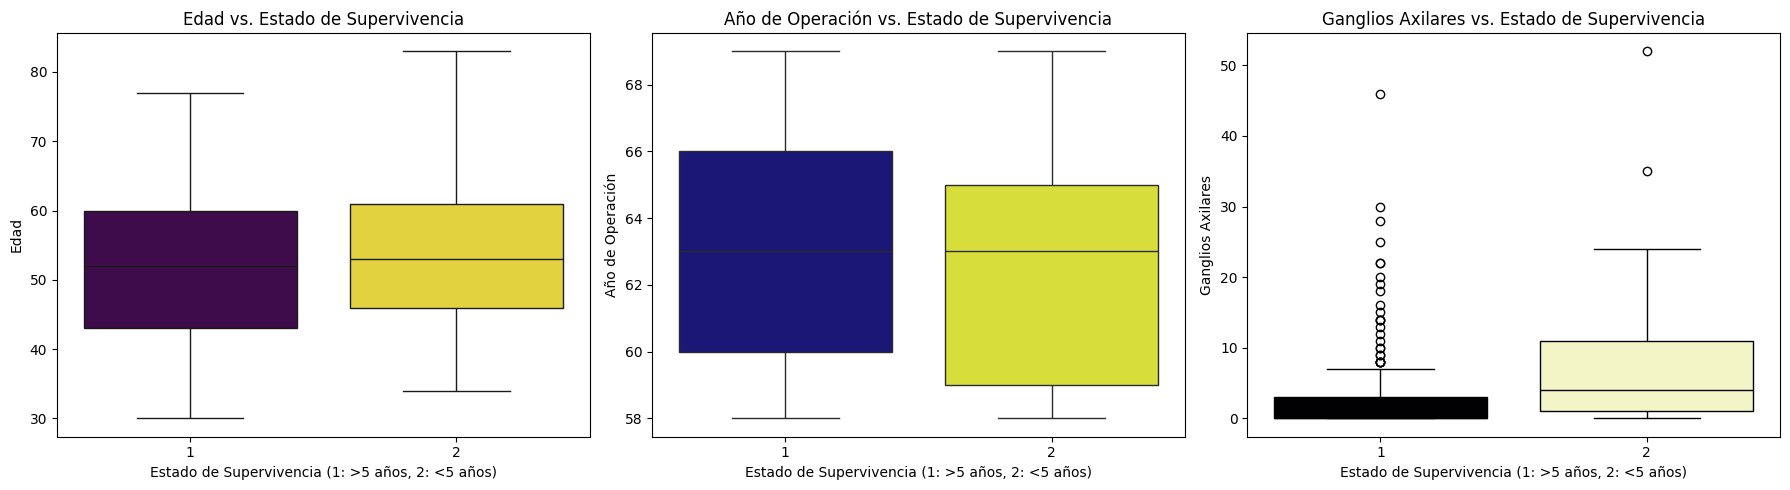

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Estado_Supervivencia', y='Edad', data=df, ax=axes[0], palette='viridis', hue='Estado_Supervivencia', legend=False)
axes[0].set_title('Edad vs. Estado de Supervivencia')
axes[0].set_xlabel('Estado de Supervivencia (1: >5 años, 2: <5 años)')
axes[0].set_ylabel('Edad')

sns.boxplot(x='Estado_Supervivencia', y='Año_Operacion', data=df, ax=axes[1], palette='plasma', hue='Estado_Supervivencia', legend=False)
axes[1].set_title('Año de Operación vs. Estado de Supervivencia')
axes[1].set_xlabel('Estado de Supervivencia (1: >5 años, 2: <5 años)')
axes[1].set_ylabel('Año de Operación')

sns.boxplot(x='Estado_Supervivencia', y='Ganglios_Axilares', data=df, ax=axes[2], palette='magma', hue='Estado_Supervivencia', legend=False)
axes[2].set_title('Ganglios Axilares vs. Estado de Supervivencia')
axes[2].set_xlabel('Estado de Supervivencia (1: >5 años, 2: <5 años)')
axes[2].set_ylabel('Ganglios Axilares')

plt.tight_layout()
plt.show()

# Preparacion de Train / Test

Filas antes de eliminar outliers: 306
Filas después de eliminar outliers en Ganglios_Axilares: 266


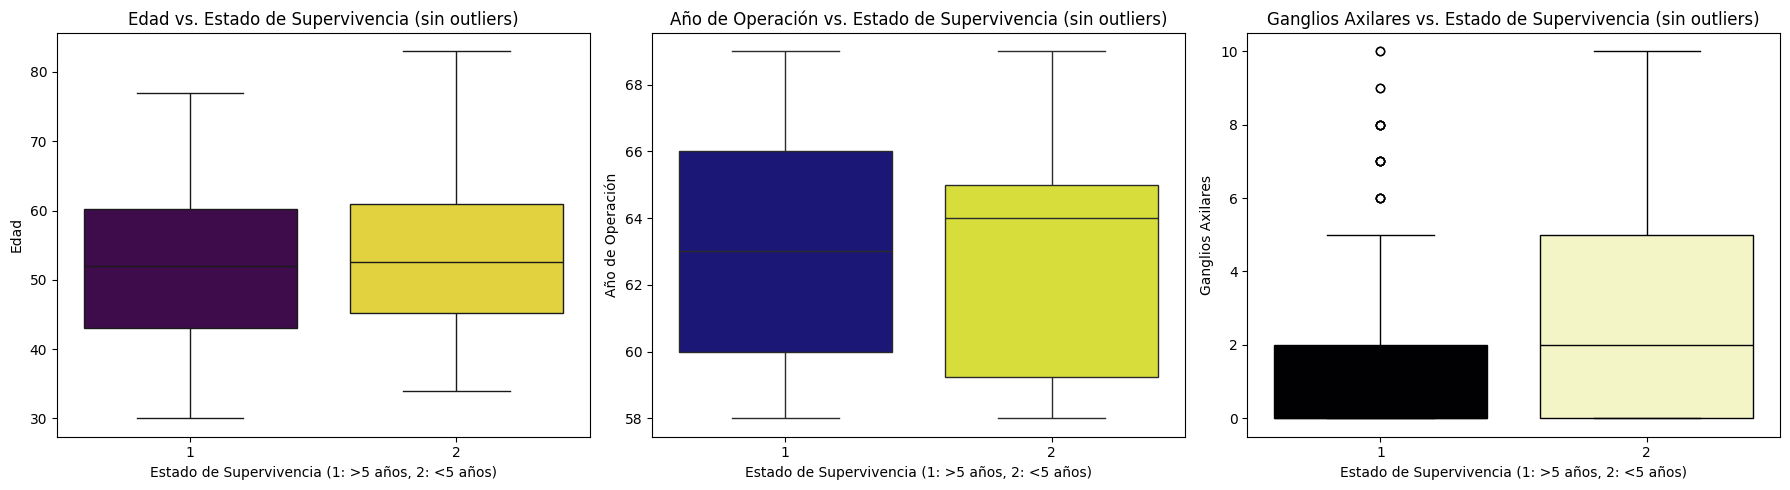

In [5]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Aplicar la función para eliminar outliers en 'Ganglios_Axilares'
df_no_outliers = remove_outliers_iqr(df.copy(), 'Ganglios_Axilares')

print(f"Filas antes de eliminar outliers: {len(df)}")
print(f"Filas después de eliminar outliers en Ganglios_Axilares: {len(df_no_outliers)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x='Estado_Supervivencia', y='Edad', data=df_no_outliers, ax=axes[0], palette='viridis', hue='Estado_Supervivencia', legend=False)
axes[0].set_title('Edad vs. Estado de Supervivencia (sin outliers)')
axes[0].set_xlabel('Estado de Supervivencia (1: >5 años, 2: <5 años)')
axes[0].set_ylabel('Edad')

sns.boxplot(x='Estado_Supervivencia', y='Año_Operacion', data=df_no_outliers, ax=axes[1], palette='plasma', hue='Estado_Supervivencia', legend=False)
axes[1].set_title('Año de Operación vs. Estado de Supervivencia (sin outliers)')
axes[1].set_xlabel('Estado de Supervivencia (1: >5 años, 2: <5 años)')
axes[1].set_ylabel('Año de Operación')

sns.boxplot(x='Estado_Supervivencia', y='Ganglios_Axilares', data=df_no_outliers, ax=axes[2], palette='magma', hue='Estado_Supervivencia', legend=False)
axes[2].set_title('Ganglios Axilares vs. Estado de Supervivencia (sin outliers)')
axes[2].set_xlabel('Estado de Supervivencia (1: >5 años, 2: <5 años)')
axes[2].set_ylabel('Ganglios Axilares')

plt.tight_layout()
plt.show()

### Preparación del Dataset para KNN

Para el algoritmo KNN, es crucial escalar las características numéricas, ya que se basa en la distancia entre los puntos de datos. Utilizaremos `StandardScaler` para normalizar las características (Edad, Año de Operación, Ganglios Axilares) y luego dividiremos el dataset en conjuntos de entrenamiento y prueba.

In [6]:
# Separar características (X) y la variable objetivo (y)
X = df_no_outliers[['Edad', 'Año_Operacion', 'Ganglios_Axilares']]
y = df_no_outliers['Estado_Supervivencia']

# Escalar las características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")

Dimensiones de X_train: (212, 3)
Dimensiones de X_test: (54, 3)
Dimensiones de y_train: (212,)
Dimensiones de y_test: (54,)


### Balance de los Datos

Es importante verificar el balance de las clases en la variable objetivo (`Estado_Supervivencia`), especialmente después de la eliminación de outliers, para determinar si es necesario aplicar técnicas de balanceo antes de entrenar el modelo.

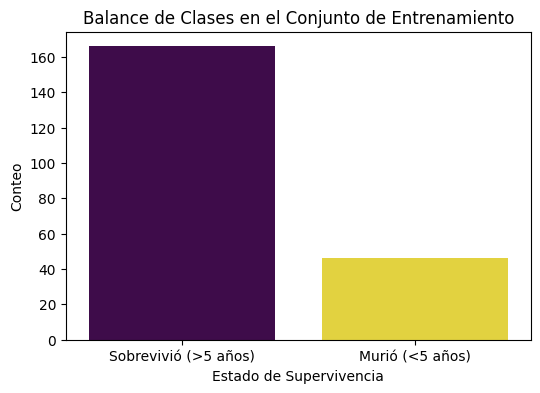

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='viridis', hue=y_train, legend=False)
plt.title('Balance de Clases en el Conjunto de Entrenamiento')
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1], labels=['Sobrevivió (>5 años)', 'Murió (<5 años)'])
plt.show()

Dimensiones de X_train después de Oversampling: (332, 3)
Dimensiones de y_train después de Oversampling: (332,)


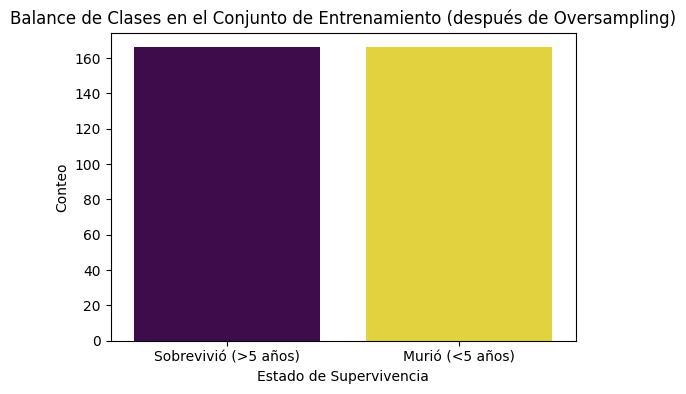

In [8]:
oversampler = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print(f"Dimensiones de X_train después de Oversampling: {X_train_resampled.shape}")
print(f"Dimensiones de y_train después de Oversampling: {y_train_resampled.shape}")

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='viridis', hue=y_train_resampled, legend=False)
plt.title('Balance de Clases en el Conjunto de Entrenamiento (después de Oversampling)')
plt.xlabel('Estado de Supervivencia')
plt.ylabel('Conteo')
plt.xticks(ticks=[0, 1], labels=['Sobrevivió (>5 años)', 'Murió (<5 años)'])
plt.show()

### Entrenamiento del Modelo KNN

Con el dataset balanceado, procederemos a entrenar un modelo de clasificación K-Nearest Neighbors (KNN). Para este primer modelo, utilizaremos `n_neighbors=5`, que es un valor comúnmente recomendado, y la métrica de distancia predeterminada (Minkowski, que se reduce a euclidiana si `p=2`).

In [9]:
# Inicializar y entrenar el modelo KNN
knn_model = KNeighborsClassifier(n_neighbors=int(np.sqrt(len(X_train_resampled))))
knn_model.fit(X_train_resampled, y_train_resampled)

print(f"Modelo KNN entrenado exitosamente con n_neighbors = {int(np.sqrt(len(X_train_resampled)))}.")

Modelo KNN entrenado exitosamente con n_neighbors = 18.


### Evaluación del Modelo KNN

Ahora, evaluaremos el rendimiento del modelo KNN entrenado en el conjunto de prueba (`X_test`, `y_test`). Utilizaremos la precisión global y la matriz de confusión para entender qué tan bien clasifica el modelo las diferentes clases.

Precisión Global del Modelo KNN: 0.4630

Matriz de Confusión:
[[18 24]
 [ 5  7]]


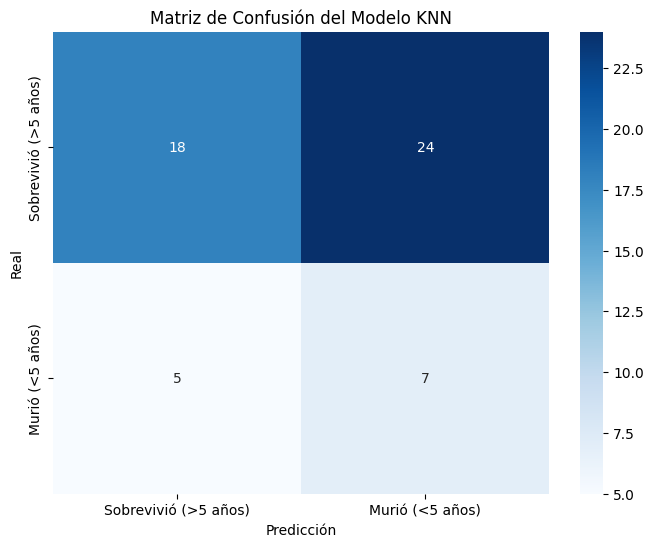


Reporte de Clasificación:
                      precision    recall  f1-score   support

Sobrevivió (>5 años)       0.78      0.43      0.55        42
     Murió (<5 años)       0.23      0.58      0.33        12

            accuracy                           0.46        54
           macro avg       0.50      0.51      0.44        54
        weighted avg       0.66      0.46      0.50        54



In [10]:
# Realizar predicciones en el conjunto de prueba
y_pred = knn_model.predict(X_test)

# Calcular la precisión global
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión Global del Modelo KNN: {accuracy:.4f}")

# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatriz de Confusión:")
print(conf_matrix)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sobrevivió (>5 años)', 'Murió (<5 años)'],
            yticklabels=['Sobrevivió (>5 años)', 'Murió (<5 años)'])
plt.title('Matriz de Confusión del Modelo KNN')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Reportes metricas
class_report = classification_report(y_test, y_pred, target_names=['Sobrevivió (>5 años)', 'Murió (<5 años)'])
print("\nReporte de Clasificación:")
print(class_report)

### Optimización Bayesiana de Hiperparámetros para KNN


In [11]:
import warnings
from tqdm.notebook import tqdm # Import tqdm for notebook

warnings.filterwarnings("ignore", category=UserWarning)

# Definir el espacio de búsqueda para los hiperparámetros de KNN
search_space = {
    'n_neighbors': Integer(3, 30),  # Ampliado el rango de vecinos a considerar
    'weights': Categorical(['uniform', 'distance']), # Tipo de peso para los vecinos
    'metric': Categorical(['euclidean', 'manhattan', 'minkowski']), # Incluir 'manhattan' y 'minkowski'
    'p': Integer(1, 2) # Parámetro para la métrica Minkowski: 1 para Manhattan, 2 para Euclídea
}

# Inicializar el clasificador KNN
knn_base = KNeighborsClassifier()

# Configurar BayesSearchCV
bayes_search = BayesSearchCV(
    estimator=knn_base,
    search_spaces=search_space,
    n_iter=40,  # Aumentado el número de iteraciones de optimización
    cv=5,       # Número de folds para la validación cruzada
    scoring='accuracy', # Métrica de evaluación
    random_state=42,
    n_jobs=-1,   # Usar todos los cores disponibles
    verbose=0    # Desactivar el verbose predeterminado para usar tqdm
)

print("Iniciando la búsqueda de hiperparámetros con Optimización Bayesiana...")

# Configurar tqdm para mostrar el progreso
pbar = tqdm(total=bayes_search.n_iter, desc="Bayesian Optimization")

# Definir un callback para actualizar tqdm
def tqdm_callback(res):
    pbar.update(1)

bayes_search.fit(X_train_resampled, y_train_resampled, callback=tqdm_callback)
pbar.close()

print("Búsqueda completada.")
print(f"Mejores hiperparámetros encontrados: {bayes_search.best_params_}")
print(f"Mejor precisión de validación cruzada: {bayes_search.best_score_:.4f}")

Iniciando la búsqueda de hiperparámetros con Optimización Bayesiana...


Bayesian Optimization:   0%|          | 0/40 [00:00<?, ?it/s]

Búsqueda completada.
Mejores hiperparámetros encontrados: OrderedDict({'metric': 'euclidean', 'n_neighbors': 3, 'p': 2, 'weights': 'distance'})
Mejor precisión de validación cruzada: 0.8735


### Evaluación del Mejor Modelo KNN (Optimizado)

Una vez que la optimización bayesiana ha encontrado los mejores hiperparámetros, evaluaremos el rendimiento del modelo KNN con estos nuevos parámetros en el conjunto de prueba (`X_test`, `y_test`).

Precisión Global del Modelo KNN Optimizado: 0.6667

Matriz de Confusión del Modelo KNN Optimizado:
[[29 13]
 [ 5  7]]


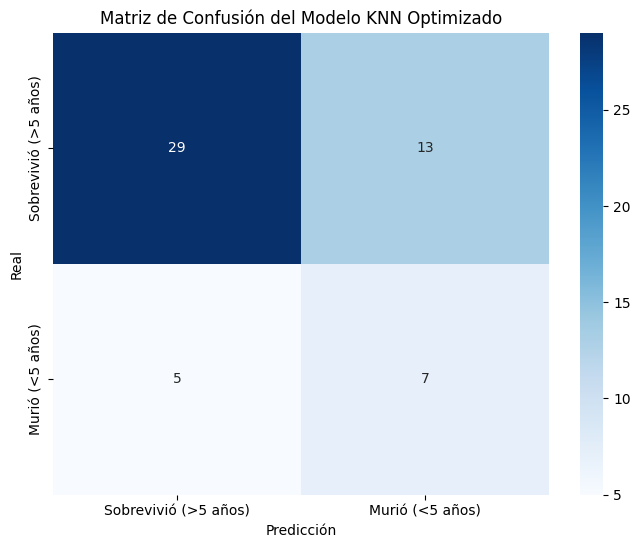


Reporte de Clasificación del Modelo KNN Optimizado:
                      precision    recall  f1-score   support

Sobrevivió (>5 años)       0.85      0.69      0.76        42
     Murió (<5 años)       0.35      0.58      0.44        12

            accuracy                           0.67        54
           macro avg       0.60      0.64      0.60        54
        weighted avg       0.74      0.67      0.69        54



In [12]:
# Obtener el mejor modelo entrenado
best_knn_model = bayes_search.best_estimator_

# Realizar predicciones en el conjunto de prueba con el mejor modelo
y_pred_tuned = best_knn_model.predict(X_test)

# Calcular la precisión global del modelo optimizado
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Precisión Global del Modelo KNN Optimizado: {accuracy_tuned:.4f}")

# Calcular y visualizar la matriz de confusión del modelo optimizado
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)
print("\nMatriz de Confusión del Modelo KNN Optimizado:")
print(conf_matrix_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sobrevivió (>5 años)', 'Murió (<5 años)'],
            yticklabels=['Sobrevivió (>5 años)', 'Murió (<5 años)'])
plt.title('Matriz de Confusión del Modelo KNN Optimizado')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Reporte de Clasificación del modelo optimizado
class_report_tuned = classification_report(y_test, y_pred_tuned, target_names=['Sobrevivió (>5 años)', 'Murió (<5 años)'])
print("\nReporte de Clasificación del Modelo KNN Optimizado:")
print(class_report_tuned)

## Experimentación Exhaustiva: Explorando Variaciones para el Mejor Desempeño

Para encontrar la configuración óptima que maximice el rendimiento del modelo, realizaremos una serie de experimentos variando los siguientes aspectos:

1.  **Tipo de Escalador:**
    *   `StandardScaler`
    *   `RobustScaler` (actualmente en uso)
2.  **Manejo de Outliers:**
    *   Con eliminación de outliers (usando el método IQR en 'Ganglios_Axilares')
    *   Sin eliminación de outliers (usando el dataset original)
3.  **Proporción de División Entrenamiento/Prueba:**
    *   80% entrenamiento / 20% prueba
    *   70% entrenamiento / 30% prueba

Cada combinación de estos parámetros se probará, y para cada una se realizará una optimización bayesiana de hiperparámetros del KNN. Registraremos los mejores resultados de cada experimento para identificar la configuración ganadora.

In [13]:
# Función para eliminar outliers (similar a la que estaba comentada)
def remove_outliers_iqr(df_input, column):
    Q1 = df_input[column].quantile(0.25)
    Q3 = df_input[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df_input[(df_input[column] >= lower_bound) & (df_input[column] <= upper_bound)]
    return df_filtered


### Feature Engineering Sugerencias

A continuación, se proponen y se implementan algunas ideas de *Feature Engineering* para crear nuevas características a partir de las existentes, con el objetivo de mejorar el rendimiento del modelo.

In [14]:
# 1. Crear 'df_full' para Feature Engineering
# Partimos del dataframe original 'df' ya que la función run_experiment manejará la eliminación de outliers.
df_full = df.copy()

# 2. Categorización de la Edad
bins = [0, 40, 60, 100] # Ejemplo de rangos de edad
labels = ['Joven', 'Mediana Edad', 'Mayor']
df_full['Edad_Categoria'] = pd.cut(df_full['Edad'], bins=bins, labels=labels, right=False)

# Convertir la categoría de edad a numérica (One-Hot Encoding o Label Encoding si se prefiere)
# Para este ejemplo, usaremos Label Encoding simple si el modelo lo requiere, o OHE si se prefiere
df_full['Edad_Categoria_Encoded'] = df_full['Edad_Categoria'].cat.codes

# 3. Interacción entre Edad y Ganglios Axilares
df_full['Edad_x_Ganglios'] = df_full['Edad'] * df_full['Ganglios_Axilares']

# 4. Interacción entre Año de Operación y Ganglios Axilares
df_full['Año_x_Ganglios'] = df_full['Año_Operacion'] * df_full['Ganglios_Axilares']

# 5. Características Polinómicas (Ejemplo para Ganglios_Axilares)
df_full['Ganglios_Axilares_Cuadrado'] = df_full['Ganglios_Axilares']**2

# Mostrar las primeras filas con las nuevas características
display(df_full.head())

,Edad,Año_Operacion,Ganglios_Axilares,Estado_Supervivencia,Edad_Categoria,Edad_Categoria_Encoded,Edad_x_Ganglios,Año_x_Ganglios,Ganglios_Axilares_Cuadrado
0,30,64,1,1,Joven,0,30,64,1
1,30,62,3,1,Joven,0,90,186,9
2,30,65,0,1,Joven,0,0,0,0
3,31,59,2,1,Joven,0,62,118,4
4,31,65,4,1,Joven,0,124,260,16


In [15]:
def run_experiment(scaler_type, use_outliers, test_split_ratio, oversampler_name, use_feature_engineering, current_experiment_idx, total_experiments, n_iter_bayes_search=30):
    print(f"\n--- Ejecutando experimento {current_experiment_idx}/{total_experiments} ---")
    print(f"Escalador: {scaler_type.__name__}, Outliers: {'Con' if use_outliers else 'Sin'}, Test Size: {test_split_ratio*100}%, Oversampler: {oversampler_name}, Feature Engineering: {'Con' if use_feature_engineering else 'Sin'}")
    print(f"Espacio de búsqueda de hiperparámetros utilizado: {search_space}")

    # 1. Selección de datos base (con/sin feature engineering)
    if use_feature_engineering:
        base_df = df_full.copy()
        feature_columns = ['Edad', 'Año_Operacion', 'Ganglios_Axilares', 'Edad_Categoria_Encoded', 'Edad_x_Ganglios', 'Año_x_Ganglios', 'Ganglios_Axilares_Cuadrado']
    else:
        base_df = df.copy() # Usar el df original sin las nuevas características
        feature_columns = ['Edad', 'Año_Operacion', 'Ganglios_Axilares'] # Características originales

    # Aplicar/No aplicar eliminación de outliers en el DataFrame base seleccionado
    if use_outliers:
        data_df = base_df.copy() # Usar el df base tal cual (con o sin FE, con outliers)
    else:
        # Eliminar outliers de 'Ganglios_Axilares' del DataFrame base
        # Se asume que 'Ganglios_Axilares' siempre existe.
        data_df = remove_outliers_iqr(base_df.copy(), 'Ganglios_Axilares')

    # Actualizar la selección de características X
    X = data_df[feature_columns]
    y = data_df['Estado_Supervivencia']

    # 2. Escalar características
    scaler = scaler_type()
    X_scaled = scaler.fit_transform(X)

    # 3. Dividir datos en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_split_ratio, random_state=42, stratify=y)

    # 4. Oversampling para balancear clases
    counts = pd.Series(y_train).value_counts()
    minority_class_label = counts.idxmin()
    num_minority_samples = counts.min()

    if oversampler_name == 'RandomOverSampler':
        oversampler = RandomOverSampler(random_state=42)
    elif oversampler_name == 'SMOTE':
        smote_k_neighbors = min(5, num_minority_samples - 1) if num_minority_samples > 1 else 1
        if num_minority_samples > 1:
            oversampler = SMOTE(random_state=42, k_neighbors=smote_k_neighbors)
        else:
            print(f"Warning: Not enough minority samples ({num_minority_samples}) for SMOTE in this experiment. Falling back to RandomOverSampler.")
            oversampler = RandomOverSampler(random_state=42)
    elif oversampler_name == 'ADASYN':
        adasyn_n_neighbors = min(5, num_minority_samples - 1) if num_minority_samples > 1 else 1
        if num_minority_samples > 1:
            oversampler = ADASYN(random_state=42, n_neighbors=adasyn_n_neighbors)
        else:
            print(f"Warning: Not enough minority samples ({num_minority_samples}) for ADASYN in this experiment. Falling back to RandomOverSampler.")
            oversampler = RandomOverSampler(random_state=42)
    elif oversampler_name == 'SMOTETomek':
        smotetomek_smote_k_neighbors = min(5, num_minority_samples - 1) if num_minority_samples > 1 else 1
        if num_minority_samples > 1:
            oversampler = SMOTETomek(random_state=42, smote=SMOTE(k_neighbors=smotetomek_smote_k_neighbors, random_state=42))
        else:
            print(f"Warning: Not enough minority samples ({num_minority_samples}) for SMOTETomek in this experiment. Falling back to RandomOverSampler.")
            oversampler = RandomOverSampler(random_state=42)
    else:
        raise ValueError("Oversampler not recognized")

    X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

    # 5. Optimización Bayesiana
    knn_base = KNeighborsClassifier()
    bayes_search = BayesSearchCV(
        estimator=knn_base,
        search_spaces=search_space,
        n_iter=n_iter_bayes_search,
        cv=5,
        scoring='accuracy',
        random_state=42,
        n_jobs=1,
        verbose=0
    )

    print(f"Iniciando BayesSearchCV para {scaler_type.__name__}, {'Con Outliers' if use_outliers else 'Sin Outliers'}, Test Size {test_split_ratio*100}%, Oversampler={oversampler_name}, FE: {use_feature_engineering}, N_iter: {n_iter_bayes_search}...")
    pbar_exp = tqdm(total=bayes_search.n_iter, desc=f"Exp {current_experiment_idx}/{total_experiments} BayesCV")
    def update_pbar(res):
        pbar_exp.update(1)
    bayes_search.fit(X_train_resampled, y_train_resampled, callback=update_pbar)
    pbar_exp.close()

    best_score = bayes_search.best_score_
    best_params = bayes_search.best_params_

    best_knn_model = bayes_search.best_estimator_
    y_pred_final = best_knn_model.predict(X_test)
    final_accuracy = accuracy_score(y_test, y_pred_final)

    print(f"Mejor CV Precisión (en entrenamiento resampleado): {best_score:.4f}")
    print(f"Mejores Hiperparámetros: {best_params}")
    print(f"Precisión Final en Test (conjunto de prueba independiente): {final_accuracy:.4f}")

    return {
        'scaler': scaler_type.__name__,
        'outliers_removed': not use_outliers,
        'test_size': test_split_ratio,
        'oversampler': oversampler_name,
        'feature_engineering': use_feature_engineering,
        'best_cv_accuracy': best_score,
        'final_test_accuracy': final_accuracy,
        'best_params': best_params,
        'n_iter_bayes_search': n_iter_bayes_search # Añadir n_iter para seguimiento
    }

### Clarificación de las Métricas de Evaluación (para una Evaluación Más Robusta)

Para una comprensión más profunda del rendimiento del modelo, es importante distinguir entre las dos métricas de precisión que estamos utilizando:

*   **`Mejor CV Precisión` (`best_cv_accuracy`):** Esta métrica proviene directamente de la `BayesSearchCV`. Representa el rendimiento medio del modelo con los mejores hiperparámetros encontrados, evaluado mediante **validación cruzada (5-fold) en el conjunto de entrenamiento resampleado**. Es una medida robusta de la capacidad del modelo para generalizar dentro del conjunto de entrenamiento, promediando los resultados de múltiples divisiones.

*   **`Precisión Final en Test` (`final_test_accuracy`):** Esta es la precisión del modelo con los mejores hiperparámetros, evaluada en un **conjunto de prueba completamente independiente y no visto (`X_test`)**. Esta métrica es crucial porque simula cómo el modelo se desempeñaría en datos nuevos del mundo real. Aunque es una única estimación (no promediada por CV como la anterior), es el indicador definitivo de la capacidad del modelo para generalizar a datos fuera del proceso de entrenamiento y validación.

Ambas métricas son complementarias. Una alta `best_cv_accuracy` con una `final_test_accuracy` mucho más baja podría indicar un sobreajuste al conjunto de entrenamiento o una división de datos no representativa. En nuestro caso, buscamos maximizar `final_test_accuracy`, mientras que `best_cv_accuracy` nos da confianza en la robustez de la selección de hiperparámetros durante el entrenamiento.

In [17]:
all_experiment_results = []

scaler_types = [StandardScaler, RobustScaler]
use_outliers_options = [True, False] # True: usar df original (con outliers), False: usar df_no_outliers
test_size_options = [0.2, 0.3]
oversampler_options = ['RandomOverSampler', 'SMOTE', 'ADASYN', 'SMOTETomek']
use_feature_engineering_options = [True, False] # Nueva opción para incluir/excluir FE

total_experiments = len(scaler_types) * len(use_outliers_options) * len(test_size_options) * len(oversampler_options) * len(use_feature_engineering_options)
current_experiment_idx = 0

outer_pbar = tqdm(total=total_experiments, desc="Overall Experiment Progress")

for scaler_t in scaler_types:
    for use_outl in use_outliers_options:
        for ts_ratio in test_size_options:
            for oversampler_opt in oversampler_options:
                for use_fe in use_feature_engineering_options: # Nuevo loop para Feature Engineering
                    current_experiment_idx += 1
                    # Pasar n_iter_bayes_search con el valor predeterminado (30) o el que se desee para la búsqueda exhaustiva inicial
                    result = run_experiment(scaler_t, use_outl, ts_ratio, oversampler_opt, use_fe, current_experiment_idx, total_experiments, n_iter_bayes_search=40)
                    all_experiment_results.append(result)
                    outer_pbar.update(1)

outer_pbar.close()

# Imprimir todos los resultados en un formato fácil de leer
print("\n--- Resumen de Todos los Experimentos ---")
for res in all_experiment_results:
    print(f"Escalador: {res['scaler']}, Outliers Removidos: {res['outliers_removed']}, Test Size: {res['test_size']:.1f}, Oversampler: {res['oversampler']}, Feature Engineering: {res['feature_engineering']}")
    print(f"  -> Mejor CV Precisión: {res['best_cv_accuracy']:.4f}, Precisión en Test: {res['final_test_accuracy']:.4f}")
    print(f"  -> Hiperparámetros: {res['best_params']}\n")

# Encontrar el mejor resultado general
best_overall_result = max(all_experiment_results, key=lambda x: x['final_test_accuracy'])

print("\n--- Mejor Configuración General ---")
print(f"Escalador: {best_overall_result['scaler']}")
print(f"Outliers Removidos: {best_overall_result['outliers_removed']}")
print(f"Test Size: {best_overall_result['test_size']:.1f}")
print(f"Oversampler: {best_overall_result['oversampler']}")
print(f"Feature Engineering: {best_overall_result['feature_engineering']}")
print(f"Mejor CV Precisión: {best_overall_result['best_cv_accuracy']:.4f}")
print(f"Precisión Final en Test: {best_overall_result['final_test_accuracy']:.4f}")
print(f"Mejores Hiperparámetros: {best_overall_result['best_params']}")

# Convertir los resultados a un DataFrame para un análisis más sencillo
results_df = pd.DataFrame(all_experiment_results)

# Ordenar por precisión final en test para ver los mejores resultados primero
results_df_sorted = results_df.sort_values(by='final_test_accuracy', ascending=False).reset_index(drop=True)

print("\n--- Top 10 Configuraciones de Experimentos por Precisión Final en Test ---")
display(results_df_sorted.head(10))

Overall Experiment Progress:   0%|          | 0/64 [00:00<?, ?it/s]


--- Ejecutando experimento 1/64 ---
Escalador: StandardScaler, Outliers: Con, Test Size: 20.0%, Oversampler: RandomOverSampler, Feature Engineering: Con
Espacio de búsqueda de hiperparámetros utilizado: {'n_neighbors': Integer(low=3, high=30, prior='uniform', transform='normalize'), 'weights': Categorical(categories=('uniform', 'distance'), prior=None), 'metric': Categorical(categories=('euclidean', 'manhattan', 'minkowski'), prior=None), 'p': Integer(low=1, high=2, prior='uniform', transform='normalize')}
Iniciando BayesSearchCV para StandardScaler, Con Outliers, Test Size 20.0%, Oversampler=RandomOverSampler, FE: True, N_iter: 40...


Exp 1/64 BayesCV:   0%|          | 0/40 [00:00<?, ?it/s]

Mejor CV Precisión (en entrenamiento resampleado): 0.8633
Mejores Hiperparámetros: OrderedDict({'metric': 'euclidean', 'n_neighbors': 23, 'p': 2, 'weights': 'distance'})
Precisión Final en Test (conjunto de prueba independiente): 0.5000

--- Ejecutando experimento 2/64 ---
Escalador: StandardScaler, Outliers: Con, Test Size: 20.0%, Oversampler: RandomOverSampler, Feature Engineering: Sin
Espacio de búsqueda de hiperparámetros utilizado: {'n_neighbors': Integer(low=3, high=30, prior='uniform', transform='normalize'), 'weights': Categorical(categories=('uniform', 'distance'), prior=None), 'metric': Categorical(categories=('euclidean', 'manhattan', 'minkowski'), prior=None), 'p': Integer(low=1, high=2, prior='uniform', transform='normalize')}
Iniciando BayesSearchCV para StandardScaler, Con Outliers, Test Size 20.0%, Oversampler=RandomOverSampler, FE: False, N_iter: 40...


Exp 2/64 BayesCV:   0%|          | 0/40 [00:00<?, ?it/s]

...

Exp 63/64 BayesCV:   0%|          | 0/40 [00:00<?, ?it/s]

Mejor CV Precisión (en entrenamiento resampleado): 0.7834
Mejores Hiperparámetros: OrderedDict({'metric': 'manhattan', 'n_neighbors': 4, 'p': 1, 'weights': 'distance'})
Precisión Final en Test (conjunto de prueba independiente): 0.6250

--- Ejecutando experimento 64/64 ---
Escalador: RobustScaler, Outliers: Sin, Test Size: 30.0%, Oversampler: SMOTETomek, Feature Engineering: Sin
Espacio de búsqueda de hiperparámetros utilizado: {'n_neighbors': Integer(low=3, high=30, prior='uniform', transform='normalize'), 'weights': Categorical(categories=('uniform', 'distance'), prior=None), 'metric': Categorical(categories=('euclidean', 'manhattan', 'minkowski'), prior=None), 'p': Integer(low=1, high=2, prior='uniform', transform='normalize')}
Iniciando BayesSearchCV para RobustScaler, Sin Outliers, Test Size 30.0%, Oversampler=SMOTETomek, FE: False, N_iter: 40...


Exp 64/64 BayesCV:   0%|          | 0/40 [00:00<?, ?it/s]

Mejor CV Precisión (en entrenamiento resampleado): 0.8421
Mejores Hiperparámetros: OrderedDict({'metric': 'manhattan', 'n_neighbors': 5, 'p': 2, 'weights': 'distance'})
Precisión Final en Test (conjunto de prueba independiente): 0.6125

--- Resumen de Todos los Experimentos ---
Escalador: StandardScaler, Outliers Removidos: False, Test Size: 0.2, Oversampler: RandomOverSampler, Feature Engineering: True
  -> Mejor CV Precisión: 0.8633, Precisión en Test: 0.5000
  -> Hiperparámetros: OrderedDict({'metric': 'euclidean', 'n_neighbors': 23, 'p': 2, 'weights': 'distance'})

Escalador: StandardScaler, Outliers Removidos: False, Test Size: 0.2, Oversampler: RandomOverSampler, Feature Engineering: False
  -> Mejor CV Precisión: 0.8605, Precisión en Test: 0.5161
  -> Hiperparámetros: OrderedDict({'metric': 'minkowski', 'n_neighbors': 27, 'p': 1, 'weights': 'distance'})

Escalador: StandardScaler, Outliers Removidos: False, Test Size: 0.2, Oversampler: SMOTE, Feature Engineering: True
  -> Mejor

,scaler,outliers_removed,test_size,oversampler,feature_engineering,best_cv_accuracy,final_test_accuracy,best_params,n_iter_bayes_search
0,RobustScaler,False,0.3,SMOTE,False,0.783769,0.695652,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",40
1,RobustScaler,False,0.3,SMOTETomek,False,0.837145,0.695652,"{'metric': 'manhattan', 'n_neighbors': 4, 'p':...",40
2,StandardScaler,True,0.2,RandomOverSampler,False,0.873451,0.666667,"{'metric': 'euclidean', 'n_neighbors': 3, 'p':...",40
3,StandardScaler,False,0.3,SMOTETomek,True,0.866394,0.663043,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",40
4,StandardScaler,False,0.3,SMOTE,True,0.828315,0.663043,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",40
5,RobustScaler,True,0.3,RandomOverSampler,False,0.865517,0.662500,"{'metric': 'manhattan', 'n_neighbors': 8, 'p':...",40
6,RobustScaler,True,0.3,ADASYN,False,0.810345,0.662500,"{'metric': 'manhattan', 'n_neighbors': 3, 'p':...",40
7,StandardScaler,True,0.3,RandomOverSampler,True,0.848276,0.662500,"{'metric': 'minkowski', 'n_neighbors': 8, 'p':...",40
8,StandardScaler,True,0.3,RandomOverSampler,False,0.862069,0.650000,"{'metric': 'euclidean', 'n_neighbors': 30, 'p'...",40
9,StandardScaler,False,0.3,SMOTETomek,False,0.824590,0.641304,"{'metric': 'minkowski', 'n_neighbors': 4, 'p':...",40
